In [ ]:
import os
import torch
import time

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm
from sklearn.decomposition import PCA
from collections import defaultdict
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from kll_sketch import*


In [1]:
###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        # {
        #     "name": "wikitext",
        #     "config": "wikitext-2-raw-v1",
        #     "split": "train",
        #     "text_column": "text"
        # },
        # {
        #     "name": "ag_news",
        #     "config": None,
        #     "split": "train",
        #     "text_column": "text"
        # },
    ],
    "max_texts": 1000,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "results_multidataset",
    "num_seeds": 1,  # Number of repeated trials for error bars
}

os.makedirs(args["output_dir"], exist_ok=True)


In [ ]:
###############################################################################
# 1) Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

In [2]:
import math
import time
import random
import numpy as np
import torch
from collections import defaultdict
from datasets import load_dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.decomposition import PCA
from tqdm import tqdm

# ---------------------------------------------------------------------------
# Original distance functions
# ---------------------------------------------------------------------------
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))

def minkowski_distance(x, y, p=3):
    return np.sum(np.abs(x - y) ** p) ** (1.0 / p)

def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))

def canberra_distance(x, y):
    numerator = np.abs(x - y)
    denominator = np.abs(x) + np.abs(y) + 1e-12
    return np.sum(numerator / denominator)

DISTANCE_FUNCTIONS = {
    "euclidean": euclidean_distance,
    "manhattan": manhattan_distance,
    "minkowski": lambda u, v: minkowski_distance(u, v, p=3),
    "chebyshev": chebyshev_distance,
    "canberra": canberra_distance,
}

# ---------------------------------------------------------------------------
# Example KLL sketch placeholder
# ---------------------------------------------------------------------------
# Assume the user has a real KLL implementation elsewhere.
# Here, we just define a skeleton for demonstration.
class KLL:
    def __init__(self, k):
        self.k = k
        self.data = []  # store values in a list for simplicity

    def insert(self, value):
        self.data.append(value)
        # In a real KLL, we'd do merges here to keep size ~ k

    def cdf(self):
        # Return a list of (value, cumulative_prob) pairs.
        if not self.data:
            return []
        sorted_vals = sorted(self.data)
        n = len(sorted_vals)
        cdf_vals = []
        cum = 0
        for i, val in enumerate(sorted_vals):
            cum += 1 / n
            cdf_vals.append((val, cum))
        return cdf_vals

# ---------------------------------------------------------------------------
# Utility Functions
# ---------------------------------------------------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

# Simple function to drift text
# (the user presumably has a more complete version)
def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

# Stub for extracting embeddings. The user can adapt as needed.
def extract_embeddings(model, tokenizer, texts, device):
    # Ensure padding token is set
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token  # Set pad token to EOS token

    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

        # Handle different architectures
        if hasattr(outputs, 'last_hidden_state'):
            hidden_states = outputs.last_hidden_state
            if model.config.model_type in ["gpt2", "gpt_neo", "opt", "mistral", "falcon", "bloom"]:
                return hidden_states[:, -1, :].cpu().numpy()  # Use last token embedding (decoder models)
            elif model.config.model_type in ["t5", "mbart"]:
                return hidden_states.mean(dim=1).cpu().numpy()  # Mean pooling for encoder-decoder models
            elif "bert" in model.config.model_type or "electra" in model.config.model_type:
                return hidden_states[:, 0, :].cpu().numpy()  # Use CLS token embedding for BERT-like models

        return None  # Handle unsupported cases

# ---------------------------------------------------------------------------
# EmbeddingTracker with optional KLL
# ---------------------------------------------------------------------------
class EmbeddingTracker:
    """
    A tracker that maintains:
    - An exponential-moving-average (EMA) of the embedding mean
    - An EMA-based covariance (if using Mahalanobis distance)
      *with optional diagonal or block-diagonal approximations*.
    - (New) An optional KLL sketch for rank-based statistics of drift distances.
    """

    def __init__(
        self,
        embedding_dim,
        alpha=0.01,
        distance_name="mahalanobis",
        use_kll=False,
        kll_k=200,
        cov_approx_mode="diagonal",
        block_size=32
    ):
        """
        :param embedding_dim: Dimension of the embeddings
        :param alpha: Smoothing factor for EMA updates
        :param distance_name: "mahalanobis" or a key in DISTANCE_FUNCTIONS
        :param use_kll: If True, maintain a KLL sketch of drift distances
        :param kll_k: The 'k' parameter for KLL (sketch size)
        :param cov_approx_mode: "full", "diagonal", or "block"
        :param block_size: if using "block" approximation, each block is block_size x block_size
        """
        self.alpha = alpha
        self.distance_name = distance_name
        self.use_kll = use_kll
        self.cov_approx_mode = cov_approx_mode.lower()
        self.block_size = block_size

        # Basic stats for mean/cov updates
        self.mean = np.zeros((embedding_dim,))
        self.count = 0

        # Covariance storage
        if self.distance_name == "mahalanobis":
            if self.cov_approx_mode == "full":
                # Full matrix
                self.cov = np.eye(embedding_dim)
            elif self.cov_approx_mode == "diagonal":
                # Store only the diagonal as a 1D array
                self.var_diag = np.ones(embedding_dim)
            elif self.cov_approx_mode == "block":
                self.blocks = []
                self.block_indices = []
                start = 0
                while start < embedding_dim:
                    end = min(start + block_size, embedding_dim)
                    size = end - start
                    self.blocks.append(np.eye(size))
                    self.block_indices.append((start, end))
                    start += block_size
            else:
                raise ValueError(f"Unknown cov_approx_mode: {self.cov_approx_mode}")

        # If requested, keep a KLL sketch for distances
        if self.use_kll:
            self.distance_kll = KLL(kll_k)

    def update(self, embedding):
        """
        Update the running mean (and covariance, if Mahalanobis).
        Optionally insert the drift distance into the KLL sketch.
        """
        if self.count == 0:
            # First observation sets the baseline
            self.mean = embedding.copy()
            if self.distance_name == "mahalanobis":
                if self.cov_approx_mode == "full":
                    self.cov = np.eye(len(embedding))
                elif self.cov_approx_mode == "diagonal":
                    self.var_diag = np.ones_like(embedding)
                elif self.cov_approx_mode == "block":
                    for i, (start, end) in enumerate(self.block_indices):
                        size = end - start
                        self.blocks[i] = np.eye(size)
        else:
            diff = embedding - self.mean
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding

            if self.distance_name == "mahalanobis":
                diff_new = embedding - self.mean
                if self.cov_approx_mode == "full":
                    outer = np.outer(diff_new, diff_new)
                    self.cov = (1 - self.alpha) * self.cov + self.alpha * outer
                elif self.cov_approx_mode == "diagonal":
                    self.var_diag = (1 - self.alpha) * self.var_diag + self.alpha * (diff_new ** 2)
                elif self.cov_approx_mode == "block":
                    for i, (start, end) in enumerate(self.block_indices):
                        d_block = diff_new[start:end]
                        outer = np.outer(d_block, d_block)
                        self.blocks[i] = (1 - self.alpha) * self.blocks[i] + self.alpha * outer

        self.count += 1

        # Insert distance into KLL if enabled
        if self.use_kll:
            dist = self.compute_distance(embedding)
            self.distance_kll.insert(dist)

    def compute_distance(self, embedding):
        """Compute distance between 'embedding' and the tracker's current mean."""
        if self.distance_name == "mahalanobis":
            diff = embedding - self.mean
            if self.cov_approx_mode == "full":
                cov_inv = np.linalg.pinv(self.cov)
                return np.sqrt(diff.T @ cov_inv @ diff)
            elif self.cov_approx_mode == "diagonal":
                safe_var = np.where(self.var_diag > 1e-12, self.var_diag, 1e-12)
                return np.sqrt(np.sum((diff**2) / safe_var))
            elif self.cov_approx_mode == "block":
                total = 0.0
                for i, (start, end) in enumerate(self.block_indices):
                    d_block = diff[start:end]
                    block_inv = np.linalg.pinv(self.blocks[i])
                    total += d_block.T @ block_inv @ d_block
                return math.sqrt(total)
        else:
            dist_fn = DISTANCE_FUNCTIONS[self.distance_name]
            return dist_fn(self.mean, embedding)

    def get_distance_quantile(self, q):
        if not self.use_kll:
            raise ValueError("KLL not enabled in this tracker. Set use_kll=True.")
        cdf_vals = self.distance_kll.cdf()
        if not cdf_vals:
            return 0.0
        for value, c_prob in cdf_vals:
            if c_prob >= q:
                return value
        return cdf_vals[-1][0]


# ---------------------------------------------------------------------------
# 4) Single-Seed Data Collection
# ---------------------------------------------------------------------------
def collect_data_single_seed(seed):
    """Run the entire process once for a given seed."""
    set_seed(seed)
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name).to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # Fit PCA on the baseline embeddings
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)

            key = (dataset_name, model_name)

            all_distance_names = ["mahalanobis"] + list(DISTANCE_FUNCTIONS.keys())

            for distance_name in all_distance_names:
                for drift_strength in args["drift_strengths"]:
                    drifted_texts = introduce_gradual_drift(drift_texts, fraction_shuffle=drift_strength)
                    test_texts = baseline_texts + drifted_texts

                    # Tracker 1: Original Approach
                    tracker_original = EmbeddingTracker(
                        embedding_dim=baseline_embs.shape[1],
                        alpha=0.01,
                        distance_name=distance_name,
                        use_kll=False
                    )
                    time_overhead_original = []
                    dist_original_values = []

                    # Tracker 2: KLL-Enhanced Approach
                    tracker_kll = EmbeddingTracker(
                        embedding_dim=baseline_embs.shape[1],
                        alpha=0.01,
                        distance_name=distance_name,
                        use_kll=True,
                        kll_k=200
                    )
                    time_overhead_kll = []
                    dist_kll_values = []

                    # Initialize both trackers with Baseline
                    for batch in batch_generator(baseline_texts, args["batch_size"]):
                        emb = extract_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)
                        tracker_original.update(mean_emb)
                        tracker_kll.update(mean_emb)

                    # Process test texts
                    for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                        emb = extract_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)

                        # Original Approach
                        start_time = time.time()
                        dist_original = tracker_original.compute_distance(mean_emb)
                        tracker_original.update(mean_emb)
                        time_overhead_original.append(time.time() - start_time)
                        dist_original_values.append(dist_original)

                        # KLL Approach
                        start_time = time.time()
                        dist_kll = tracker_kll.compute_distance(mean_emb)
                        tracker_kll.update(mean_emb)
                        time_overhead_kll.append(time.time() - start_time)
                        dist_kll_values.append(dist_kll)

                    avg_overhead_original = np.mean(time_overhead_original)
                    avg_overhead_kll = np.mean(time_overhead_kll)

                    # Also track final distance and average distance
                    final_dist_original = dist_original_values[-1] if dist_original_values else 0.0
                    avg_dist_original = np.mean(dist_original_values) if dist_original_values else 0.0

                    final_dist_kll = dist_kll_values[-1] if dist_kll_values else 0.0
                    avg_dist_kll = np.mean(dist_kll_values) if dist_kll_values else 0.0

                    # Store results
                    results[key].append({
                        "distance_name": distance_name,
                        "drift_strength": drift_strength,
                        "method": "original",
                        "avg_overhead": avg_overhead_original,
                        "final_distance": final_dist_original,
                        "avg_distance": avg_dist_original,
                        "seed": seed
                    })

                    results[key].append({
                        "distance_name": distance_name,
                        "drift_strength": drift_strength,
                        "method": "kll",
                        "avg_overhead": avg_overhead_kll,
                        "final_distance": final_dist_kll,
                        "avg_distance": avg_dist_kll,
                        "seed": seed
                    })

    return results

# ---------------------------------------------------------------------------
# 5) Collect Data Across Multiple Seeds
# ---------------------------------------------------------------------------
def collect_data_multiple_seeds():
    all_results = defaultdict(list)

    for seed in range(args["num_seeds"]):
        seed_results = collect_data_single_seed(seed)
        for key, records in seed_results.items():
            all_results[key].extend(records)

    print("\nAll seeds complete!")
    return all_results

# ---------------------------------------------------------------------------
# Run the Multi-Seed Experiments
# ---------------------------------------------------------------------------
all_results = collect_data_multiple_seeds()

/Users/jasper.bruin/Documents/driftwatch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---


[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---


[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---



All seeds complete!


In [3]:
import pandas as pd
import ast

def preprocess_results(all_results):
    """
    Converts the nested structure of `all_results` into a flattened DataFrame.
    """
    processed_data = []

    # Loop over the results to extract dictionary contents
    for dataset_model, records in all_results.items():
        dataset_name, model_name = dataset_model  # Tuple unpacking

        for record in records:
            # Ensure dictionary conversion from string
            if isinstance(record, str):
                record = ast.literal_eval(record)  # Convert from string to dict

            # Append additional metadata (dataset and model)
            record["Dataset"] = dataset_name
            record["Model"] = model_name
            processed_data.append(record)

    # Create DataFrame
    df_clean = pd.DataFrame(processed_data)

    # Convert necessary columns to numeric
    df_clean["drift_strength"] = pd.to_numeric(df_clean["drift_strength"], errors='coerce')
    df_clean["avg_overhead"] = pd.to_numeric(df_clean["avg_overhead"], errors='coerce')

    return df_clean

# Preprocess the results
df_clean = preprocess_results(all_results)


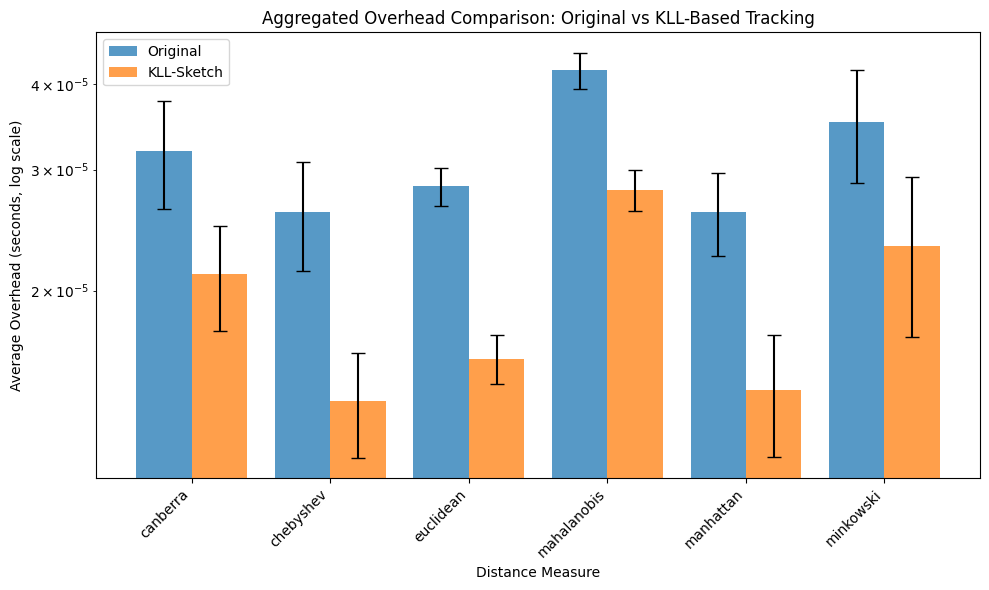

In [4]:
def plot_aggregated_time_overhead(df_clean):
    """
    Plots aggregated time overhead comparison for 6 distance measures
    (Original and KLL-based) as a grouped bar chart.

    :param df_clean: Preprocessed DataFrame containing experiment results.
    """

    # Aggregate data: Group by distance_name and method to compute mean/std
    summary = df_clean.groupby(["distance_name", "method"]).agg(
        avg_overhead=("avg_overhead", "mean"),
        std_overhead=("avg_overhead", "std")
    ).reset_index()

    # Extract unique distance measures and methods
    distance_measures = summary["distance_name"].unique()
    methods = ["original", "kll"]

    x = np.arange(len(distance_measures))  # X-axis positions for bars
    width = 0.4  # Bar width

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot bars for Original method
    original_data = summary[summary["method"] == "original"]
    ax.bar(x - width/2, original_data["avg_overhead"], width, yerr=original_data["std_overhead"],
           label="Original", capsize=5, alpha=0.75)

    # Plot bars for KLL method
    kll_data = summary[summary["method"] == "kll"]
    ax.bar(x + width/2, kll_data["avg_overhead"], width, yerr=kll_data["std_overhead"],
           label="KLL-Sketch", capsize=5, alpha=0.75)

    # Formatting
    ax.set_xlabel("Distance Measure")
    ax.set_ylabel("Average Overhead (seconds, log scale)")
    ax.set_title("Aggregated Overhead Comparison: Original vs KLL-Based Tracking")
    ax.set_xticks(x)
    ax.set_xticklabels(distance_measures, rotation=45, ha="right")
    ax.set_yscale("log")  # Logarithmic scale for better visualization
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

# Generate the plot
plot_aggregated_time_overhead(df_clean)


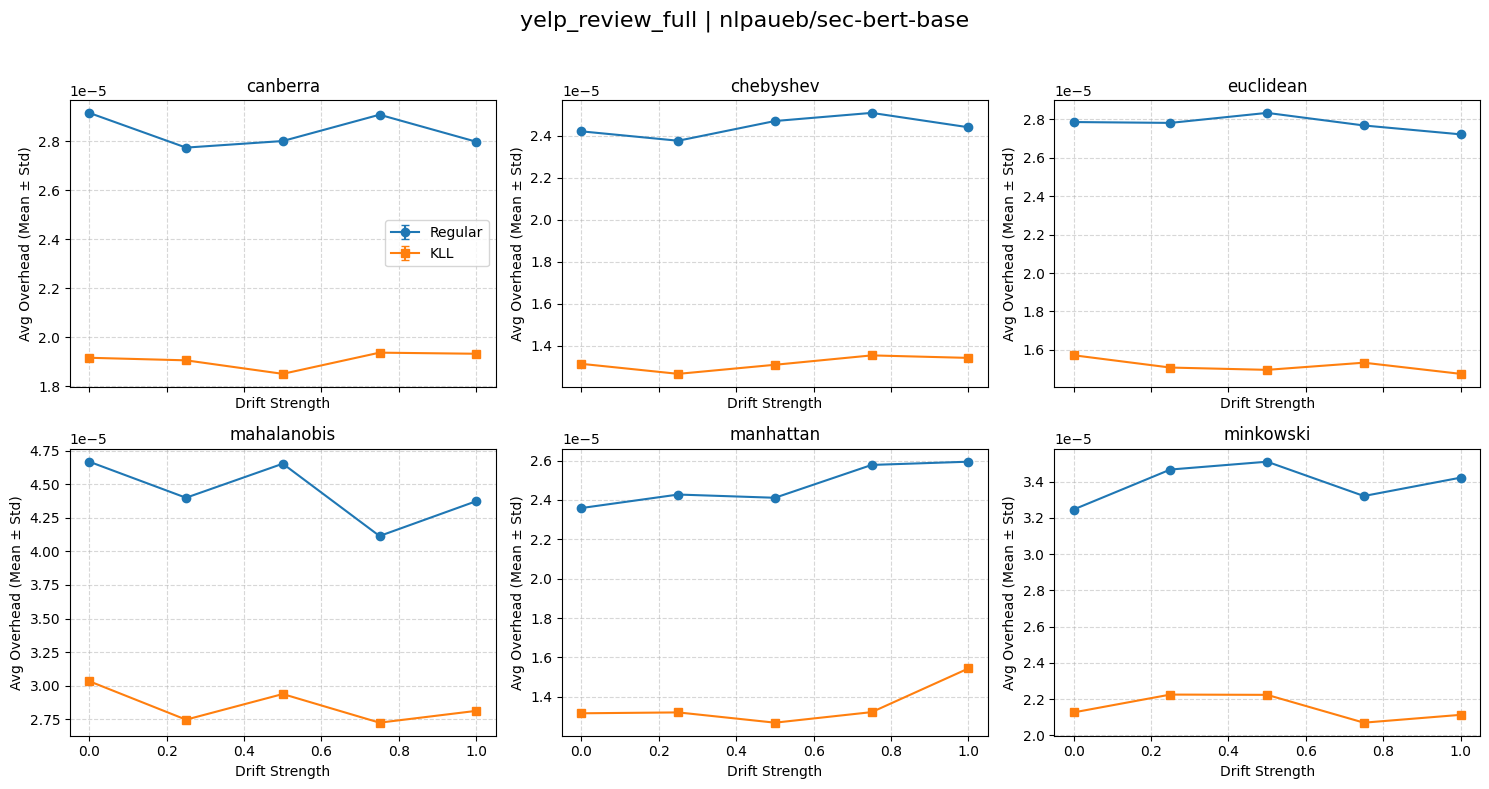

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distances_errorbars.png


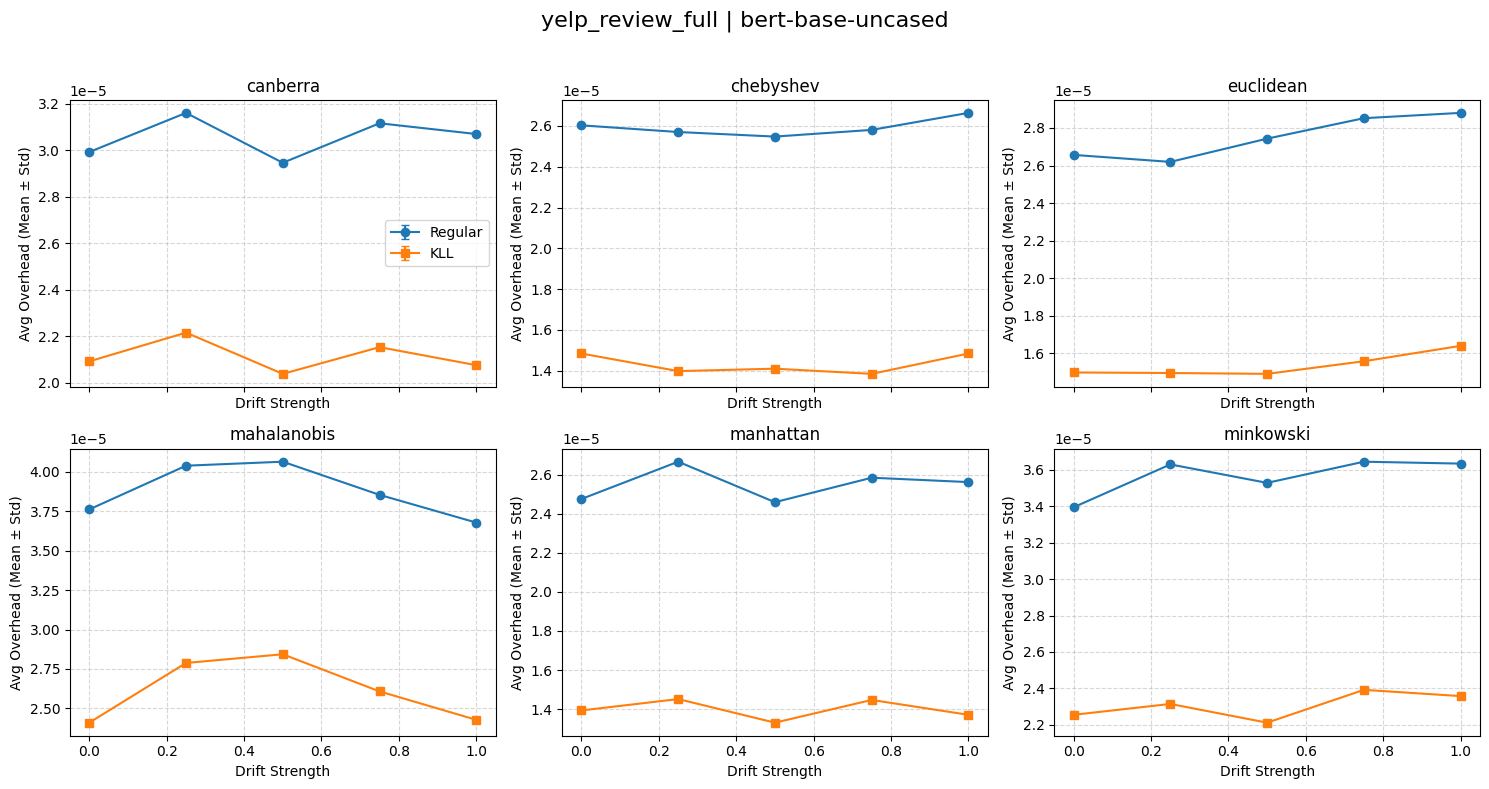

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distances_errorbars.png


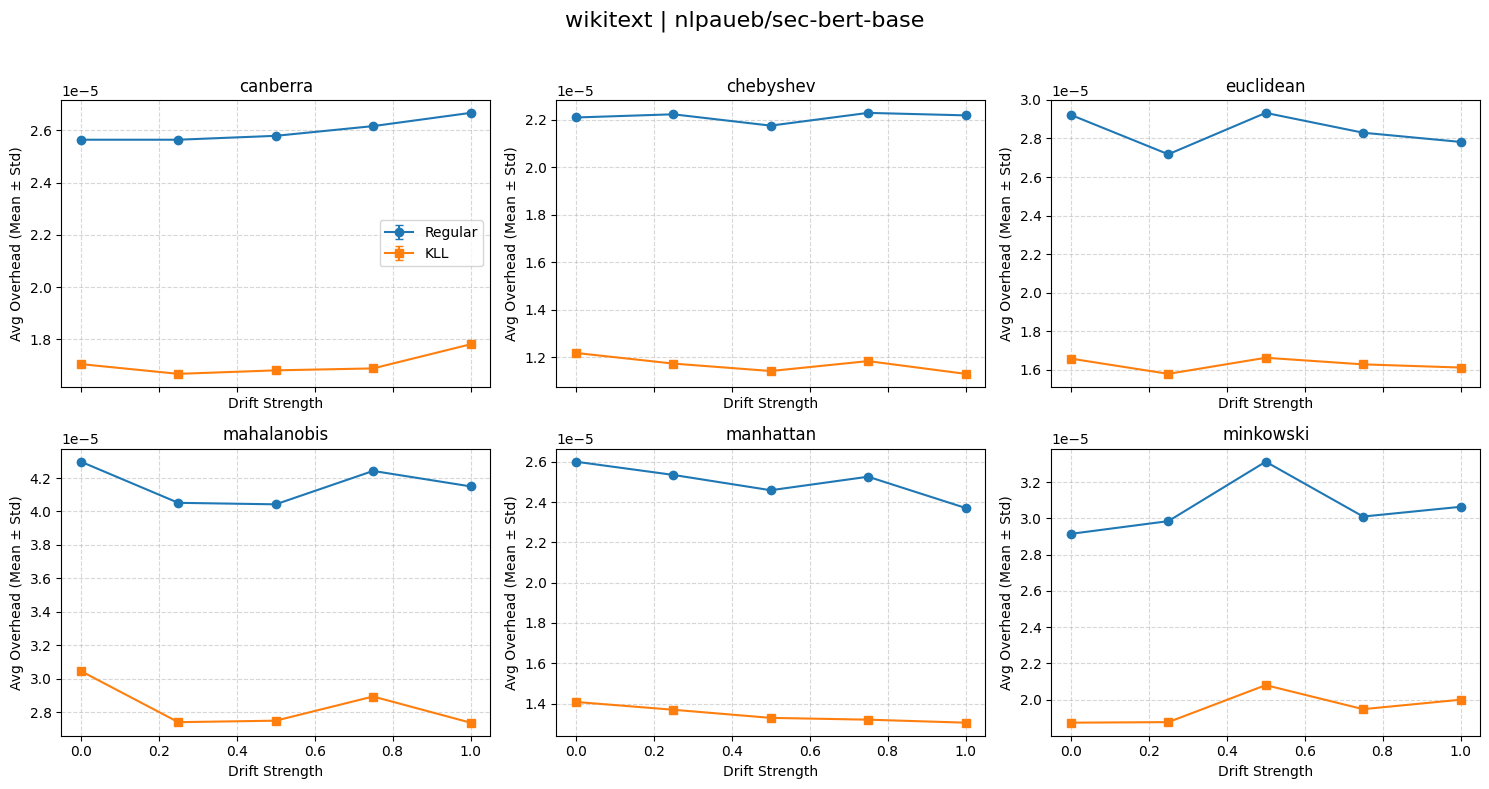

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distances_errorbars.png


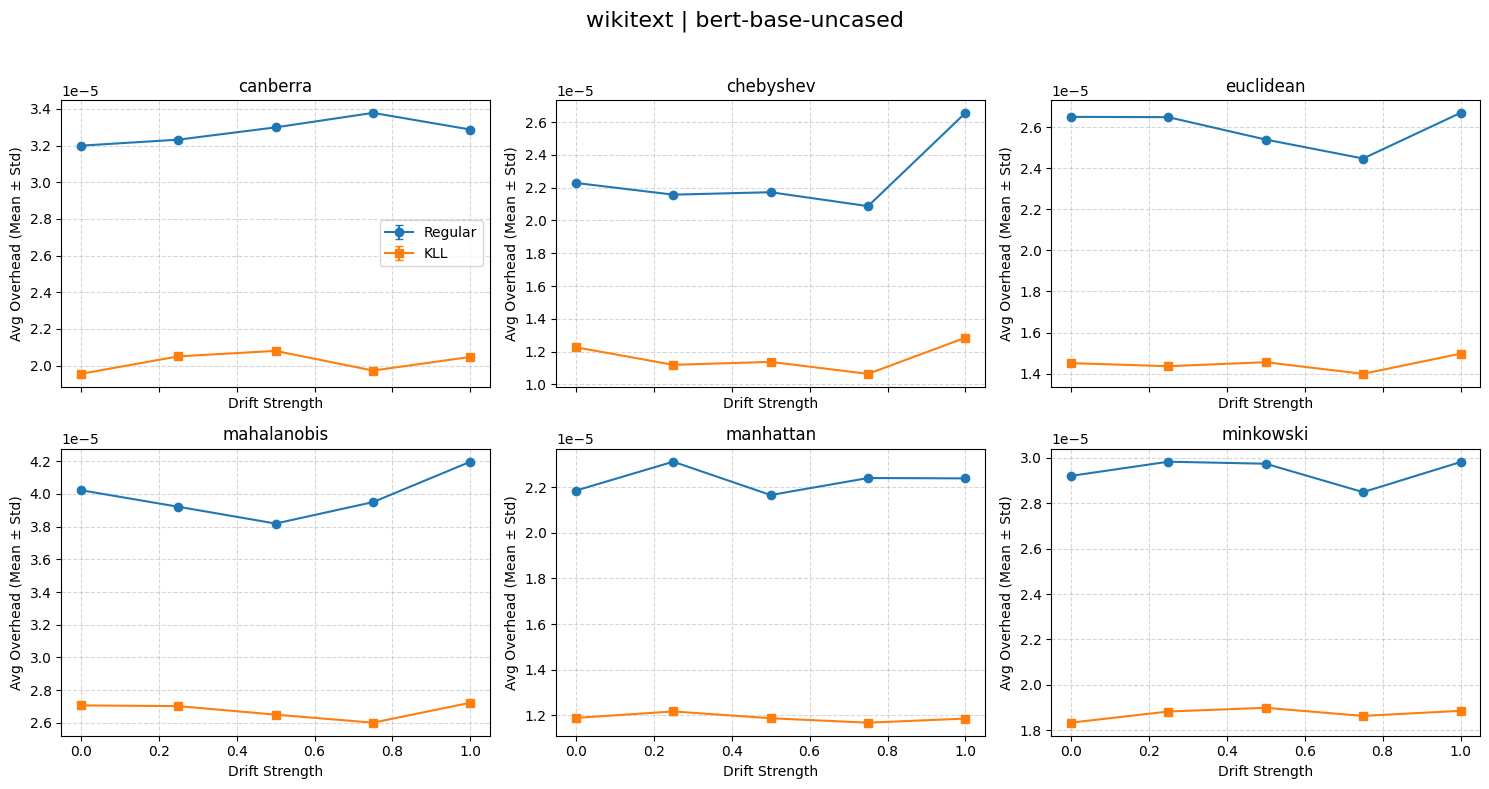

Saved figure: results_multidataset/wikitext_bert-base-uncased_distances_errorbars.png


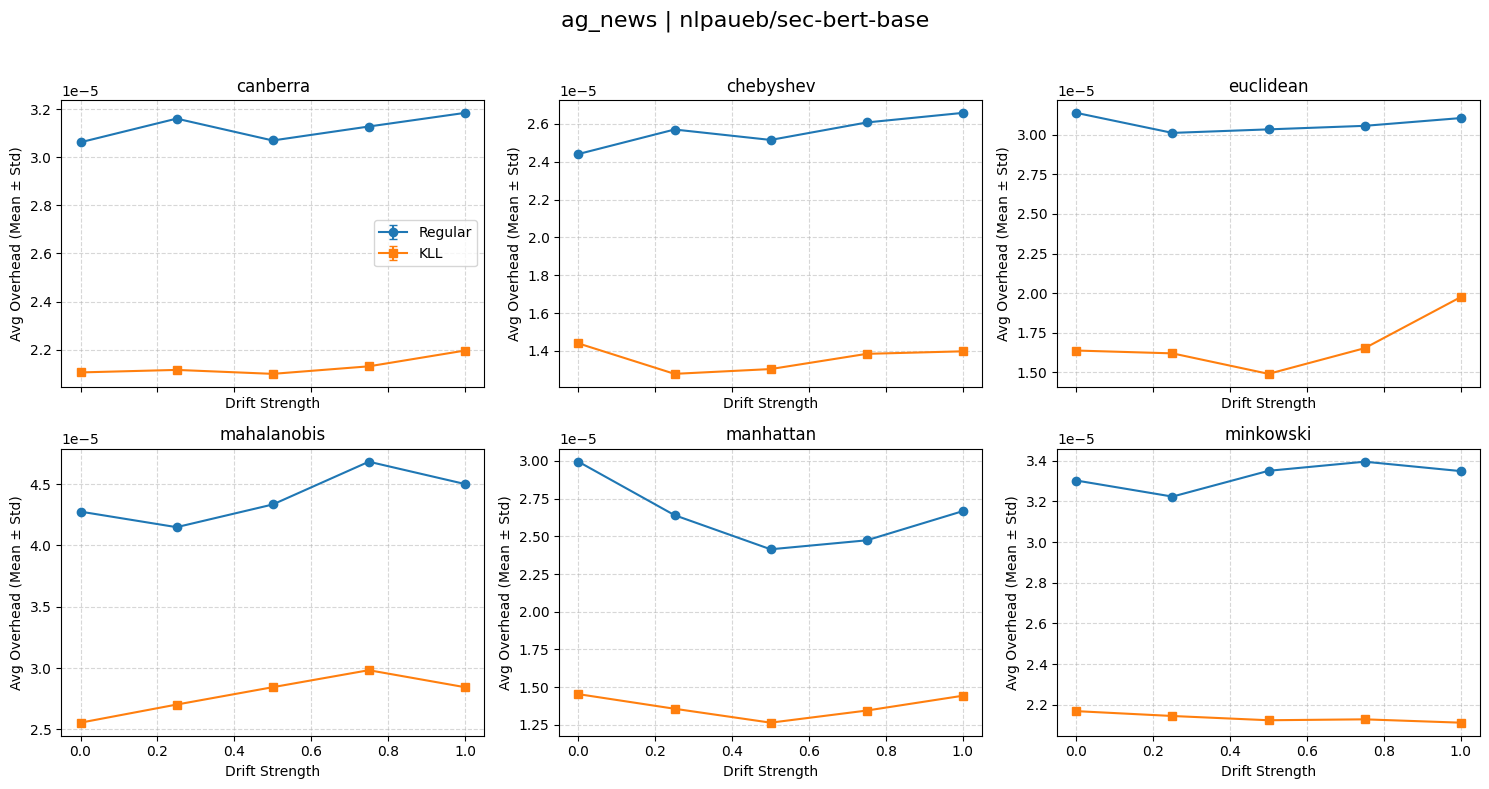

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distances_errorbars.png


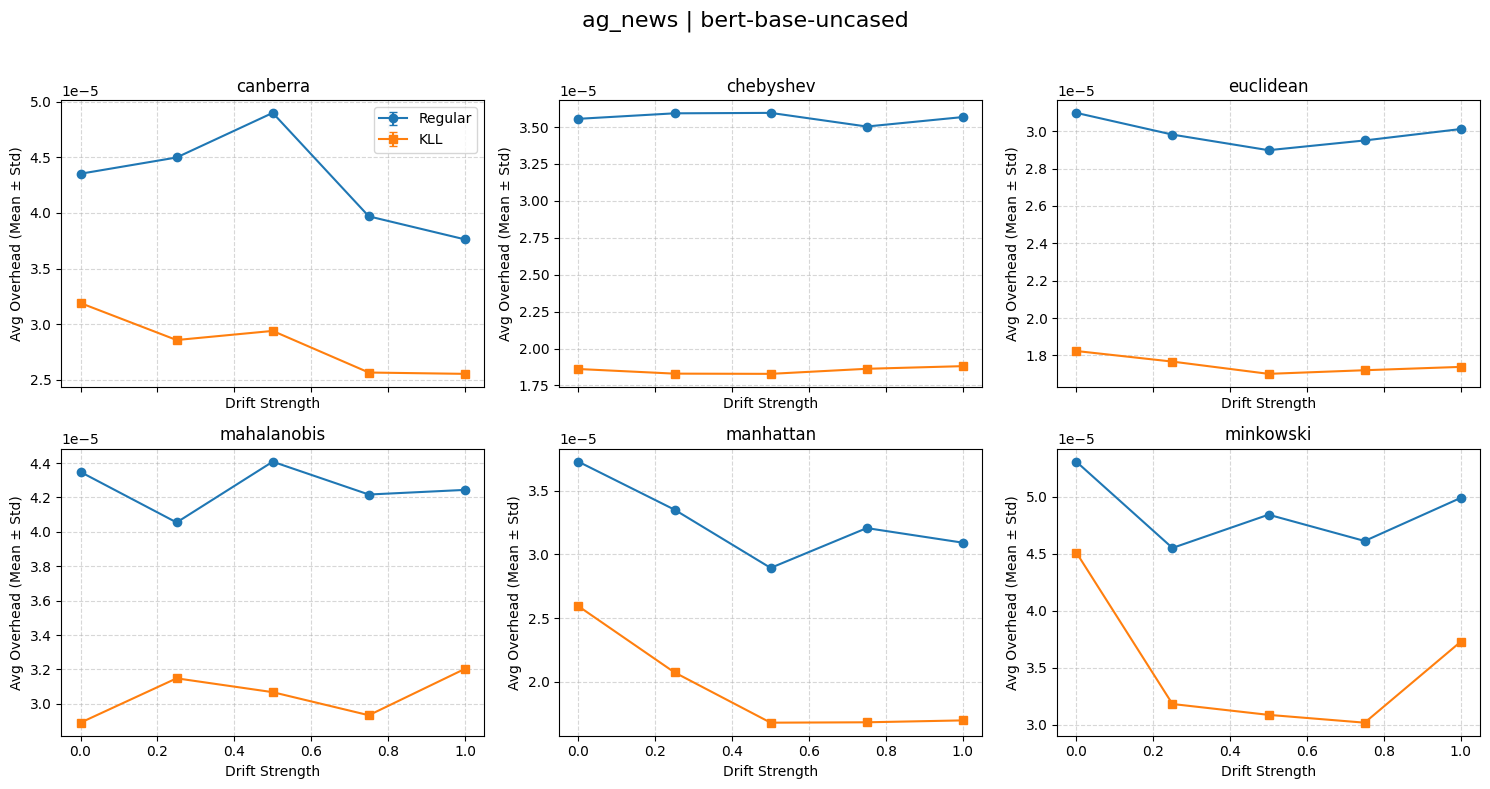

Saved figure: results_multidataset/ag_news_bert-base-uncased_distances_errorbars.png


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_distance(all_results, output_dir):
    """
    We aggregate across seeds: For each (dataset_name, model_name, distance_name, method, drift_strength),
    compute the mean + std of final_distance across seeds.
    Then we plot error bars for each drift_strength for "Regular" and "KLL" lines, without a log-scale y-axis.
    """
    # aggregated[(dataset_name, model_name, distance_name, method, drift_strength)]
    aggregator = defaultdict(list)

    for (dataset_name, model_name), records in all_results.items():
        for r in records:
            dist_name = r["distance_name"]
            drift_strength = r["drift_strength"]
            method = r["method"]  # "original" or "kll"
            avg_overhead = r["avg_overhead"]
            seed = r["seed"]

            key = (dataset_name, model_name, dist_name, method, drift_strength)
            aggregator[key].append(avg_overhead)

    # Compute mean/std
    aggregated_data = []
    for key, overhead_values in aggregator.items():
        dataset_name, model_name, dist_name, method, drift_strength = key
        mean_val = np.mean(overhead_values)
        std_val = np.std(overhead_values)
        aggregated_data.append({
            "dataset_name": dataset_name,
            "model_name": model_name,
            "distance_name": dist_name,
            "method": method,
            "drift_strength": drift_strength,
            "mean_val": mean_val,
            "std_val": std_val
        })

    # Group by (dataset_name, model_name) for plotting
    grouped = defaultdict(list)
    for row in aggregated_data:
        ds = row["dataset_name"]
        md = row["model_name"]
        grouped[(ds, md)].append(row)

    for (dataset_name, model_name), rows in grouped.items():
        dist_names = sorted(set(r["distance_name"] for r in rows))
        n_dists = len(dist_names)
        n_cols = 3
        n_rows = -(-n_dists // n_cols)  # Equivalent to math.ceil(n_dists / n_cols)
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True)
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, dist_name in enumerate(dist_names):
            ax = axs[i]
            dist_rows = [r for r in rows if r["distance_name"] == dist_name]
            regular = [r for r in dist_rows if r["method"] == "original"]
            kll = [r for r in dist_rows if r["method"] == "kll"]

            regular_sorted = sorted(regular, key=lambda x: x["drift_strength"])
            kll_sorted = sorted(kll, key=lambda x: x["drift_strength"])

            x_regular = [r["drift_strength"] for r in regular_sorted]
            y_regular = [r["mean_val"] for r in regular_sorted]
            e_regular = [r["std_val"] for r in regular_sorted]

            x_kll = [r["drift_strength"] for r in kll_sorted]
            y_kll = [r["mean_val"] for r in kll_sorted]
            e_kll = [r["std_val"] for r in kll_sorted]

            ax.errorbar(x_regular, y_regular, yerr=e_regular, fmt='-o', capsize=3, label="Regular")
            ax.errorbar(x_kll, y_kll, yerr=e_kll, fmt='-s', capsize=3, label="KLL")

            ax.set_title(dist_name)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Avg Overhead (Mean ± Std)")
            ax.grid(True, linestyle='--', alpha=0.5)

            if i == 0:
                ax.legend()

        for j in range(i + 1, n_rows * n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fname = f"{dataset_name}_{model_name.replace('/', '_')}_distances_errorbars.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved figure: {save_path}")

# Call the function with the appropriate output directory
plot_distance(all_results, output_dir=args["output_dir"])
